In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import os

os.chdir(r"C:\Users\Nandan\Desktop\Customer Segmentations")
print(os.getcwd())  # Verify the current working directory

C:\Users\Nandan\Desktop\Customer Segmentations


In [10]:
df=pd.read_csv("Order_details1.csv",encoding="latin-1")
Customer=pd.read_csv("Cust.csv")

In [11]:
df[df['Customer_ID']=='0']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country
622,536414,22139,NaN,56,12-01-2010 11:52,0.00,0,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12-01-2010 14:32,2.51,0,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12-01-2010 14:32,2.51,0,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12-01-2010 14:32,0.85,0,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12-01-2010 14:32,1.66,0,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12-09-2011 10:26,4.13,0,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12-09-2011 10:26,4.13,0,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12-09-2011 10:26,4.96,0,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12-09-2011 10:26,10.79,0,United Kingdom


In [12]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,AH-17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,AH-17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,AH-17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,AH-17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,AH-17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-2011 12:50,0.85,JR-12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-2011 12:50,2.10,JR-12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-2011 12:50,4.15,JR-12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-2011 12:50,4.15,JR-12680,France


In [13]:
df.shape

(541909, 8)

In [14]:
Customer

,Customer_ID,Customer_Name
0,AH-17850,Allison Hill
1,NR-13047,Noah Rhodes
2,AH-12583,Angie Henderson
3,DW-13748,Daniel Wagner
4,CS-15100,Cristian Santos
...,...,...
4368,HL-13436,Harold Lee
4369,CG-15520,Carol Gay
4370,MN-13298,Michael Nelson
4371,DM-14569,Daniel Meyer


# Data Cleaning

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   Customer_ID  541909 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [16]:
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
Customer_ID       0
Country           0
dtype: int64

In [17]:
df=df.dropna(subset=['Customer_ID'])

In [18]:
df.shape

(541909, 8)

In [19]:
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
Customer_ID       0
Country           0
dtype: int64

In [20]:
df['InvoiceNo'].nunique()

25900

In [21]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country
141,C536379,D,Discount,-1,12-01-2010 09:41,27.50,RM-14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12-01-2010 09:49,4.65,GD-15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12-01-2010 10:24,1.65,DZ-17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12-01-2010 10:24,0.29,DZ-17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12-01-2010 10:24,0.29,DZ-17548,United Kingdom


In [22]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [23]:
df[df['Quantity'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country
2406,536589,21777,NaN,-10,12-01-2010 16:50,0.0,0,United Kingdom
4347,536764,84952C,NaN,-38,12-02-2010 14:42,0.0,0,United Kingdom
7188,536996,22712,NaN,-20,12-03-2010 15:30,0.0,0,United Kingdom
7189,536997,22028,NaN,-20,12-03-2010 15:30,0.0,0,United Kingdom
7190,536998,85067,NaN,-6,12-03-2010 15:30,0.0,0,United Kingdom
...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,12-07-2011 18:36,0.0,0,United Kingdom
535335,581212,22578,lost,-1050,12-07-2011 18:38,0.0,0,United Kingdom
535336,581213,22576,check,-30,12-07-2011 18:38,0.0,0,United Kingdom
536908,581226,23090,missing,-338,12-08-2011 09:56,0.0,0,United Kingdom


In [24]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country
622,536414,22139,NaN,56,12-01-2010 11:52,0.0,0,United Kingdom
1970,536545,21134,NaN,1,12-01-2010 14:32,0.0,0,United Kingdom
1971,536546,22145,NaN,1,12-01-2010 14:33,0.0,0,United Kingdom
1972,536547,37509,NaN,1,12-01-2010 14:33,0.0,0,United Kingdom
1987,536549,85226A,NaN,1,12-01-2010 14:34,0.0,0,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12-08-2011 10:33,0.0,0,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12-08-2011 13:58,0.0,0,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12-08-2011 13:58,0.0,0,United Kingdom
538554,581408,85175,NaN,20,12-08-2011 14:06,0.0,0,United Kingdom


In [25]:
df=df[df['UnitPrice'] > 0]

In [26]:
df.duplicated().sum()

np.int64(5226)

In [27]:
df.drop_duplicates(inplace=True)

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df['Revenue']=(df['Quantity']*df['UnitPrice']).round(2)

In [30]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,AH-17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,AH-17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,AH-17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,AH-17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,AH-17850,United Kingdom,20.34


In [31]:
df['Description']=df['Description'].str.lower()

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524878 non-null  object 
 1   StockCode    524878 non-null  object 
 2   Description  524878 non-null  object 
 3   Quantity     524878 non-null  int64  
 4   InvoiceDate  524878 non-null  object 
 5   UnitPrice    524878 non-null  float64
 6   Customer_ID  524878 non-null  object 
 7   Country      524878 non-null  object 
 8   Revenue      524878 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 40.0+ MB


In [33]:
df['InvoiceDate'].unique()

array(['12-01-2010 08:26', '12-01-2010 08:28', '12-01-2010 08:34', ...,
       '12-09-2011 12:31', '12-09-2011 12:49', '12-09-2011 12:50'],
      shape=(18499,), dtype=object)

In [34]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format='mixed',
    dayfirst=True
)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   Customer_ID  524878 non-null  object        
 7   Country      524878 non-null  object        
 8   Revenue      524878 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 40.0+ MB


In [36]:
df['InvoiceDate']

0        2010-01-12 08:26:00
1        2010-01-12 08:26:00
2        2010-01-12 08:26:00
3        2010-01-12 08:26:00
4        2010-01-12 08:26:00
                 ...        
541904   2011-09-12 12:50:00
541905   2011-09-12 12:50:00
541906   2011-09-12 12:50:00
541907   2011-09-12 12:50:00
541908   2011-09-12 12:50:00
Name: InvoiceDate, Length: 524878, dtype: datetime64[ns]

In [37]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'Customer_ID', 'Country', 'Revenue'],
      dtype='object')

In [38]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,Revenue
count,524878.000000,524878,524878.000000,524878.000000
mean,10.616600,2011-06-16 00:16:24.503179776,3.922573,20.275399
min,1.000000,2010-01-12 08:26:00,0.001000,0.000000
25%,1.000000,2011-03-23 10:43:00,1.250000,3.900000
50%,4.000000,2011-07-03 17:22:00,2.080000,9.920000
75%,11.000000,2011-10-05 10:20:00,4.130000,17.700000
max,80995.000000,2011-12-10 17:19:00,13541.330000,168469.600000
std,156.280031,NaN,36.093028,271.693566


In [39]:
df.shape

(524878, 9)

In [40]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'Customer_ID', 'Country', 'Revenue'],
      dtype='object')

In [41]:
df['Customer_ID'].nunique()

4339

# Feature Engineering

In [42]:
# Get the maximum date from our entire data
df['InvoiceDate'].max()

Timestamp('2011-12-10 17:19:00')

In [43]:
# RFM approach and avoids having many customers with Recency = 0 for that i add one day.
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-11 17:19:00')

In [44]:
rfm = df.groupby('Customer_ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [45]:
rfm

,InvoiceDate,InvoiceNo,Revenue
Customer_ID,,,
0,1,1428,1754901.91
AA-13079,23,5,220.10
AA-13425,110,3,1624.21
AA-13805,54,2,924.60
AA-13960,23,2,230.22
...,...,...,...
ZR-13922,353,1,172.25
ZR-17859,131,1,141.92
ZS-14481,166,2,636.51


In [46]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [47]:
rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
0,1,1428,1754901.91
AA-13079,23,5,220.10
AA-13425,110,3,1624.21
AA-13805,54,2,924.60
AA-13960,23,2,230.22


In [48]:
rfm.shape

(4339, 3)

In [49]:
rfm.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4.339000e+03
mean,106.446647,4.600138,2.452664e+03
std,115.080035,22.943499,2.808606e+04
min,1.000000,1.000000,3.750000e+00
25%,23.000000,1.000000,3.065050e+02
50%,62.000000,2.000000,6.685800e+02
75%,162.500000,5.000000,1.660890e+03
max,698.000000,1428.000000,1.754902e+06


By analyzing, some customer are spend large, and some are spend low 25 percentile data has spend less than 711

In [50]:
rfm=rfm.reset_index()

In [51]:
rfm['Average_Order_Value'] = rfm['Monetary'] / rfm['Frequency']

In [52]:
rfm.sort_values(by='Average_Order_Value',ascending=False)

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value
3066,MR-16446,90,2,168472.50,84236.250000
1747,JG-12346,327,1,77183.60,77183.600000
1261,EB-15749,40,3,44534.30,14844.766667
3743,SF-15098,66,3,39916.50,13305.500000
1917,JM-12357,183,1,6207.67,6207.670000
...,...,...,...,...,...
1645,JB-18037,126,6,70.02,11.670000
1080,DK-17816,215,4,36.56,9.140000
1941,JM-14792,154,1,6.20,6.200000
579,CA-16738,299,1,3.75,3.750000


In [53]:
rfm['Customer_ID'].nunique()

4339

In [54]:
rfm.duplicated().sum()

np.int64(0)

In [55]:
rfm.isna().sum()

Customer_ID            0
Recency                0
Frequency              0
Monetary               0
Average_Order_Value    0
dtype: int64

In [56]:
rfm.describe()

,Recency,Frequency,Monetary,Average_Order_Value
count,4339.000000,4339.000000,4.339000e+03,4339.000000
mean,106.446647,4.600138,2.452664e+03,417.832708
std,115.080035,22.943499,2.808606e+04,1796.346486
min,1.000000,1.000000,3.750000e+00,3.450000
25%,23.000000,1.000000,3.065050e+02,177.869167
50%,62.000000,2.000000,6.685800e+02,292.000000
75%,162.500000,5.000000,1.660890e+03,428.323333
max,698.000000,1428.000000,1.754902e+06,84236.250000


In [57]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          4339 non-null   object 
 1   Recency              4339 non-null   int64  
 2   Frequency            4339 non-null   int64  
 3   Monetary             4339 non-null   float64
 4   Average_Order_Value  4339 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 169.6+ KB


In [58]:
rfm=rfm[~(rfm['Customer_ID']=='0')]

In [59]:
rfm

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value
1,AA-13079,23,5,220.10,44.020000
2,AA-13425,110,3,1624.21,541.403333
3,AA-13805,54,2,924.60,462.300000
4,AA-13960,23,2,230.22,115.110000
5,AA-15045,34,2,735.66,367.830000
...,...,...,...,...,...
4334,ZR-13922,353,1,172.25,172.250000
4335,ZR-17859,131,1,141.92,141.920000
4336,ZS-14481,166,2,636.51,318.255000
4337,ZV-15026,82,3,469.00,156.333333


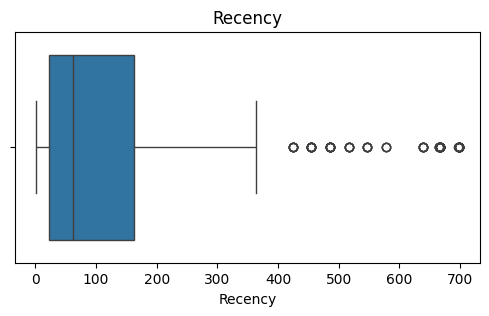

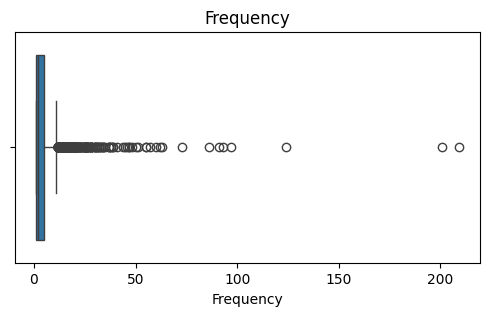

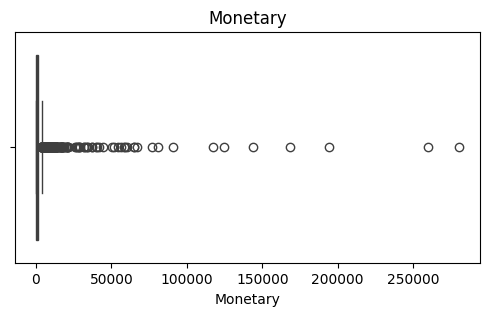

In [60]:
# Checking outliers
for col in ['Recency', 'Frequency', 'Monetary']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=rfm[col])
    plt.title(col)
    plt.show()

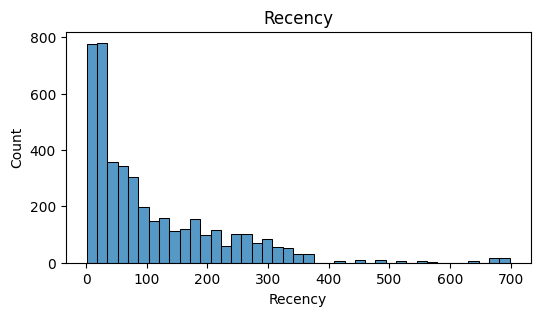

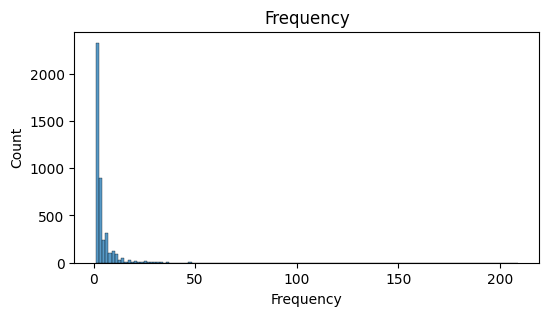

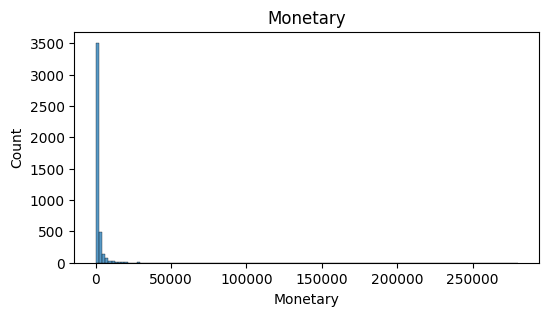

In [61]:
for col in ['Recency', 'Frequency', 'Monetary']:
    plt.figure(figsize=(6,3))
    sns.histplot(x=rfm[col])
    plt.title(col)
    plt.show()

In [62]:
# apply log transformation because they are right skewed
rfm_log = rfm.drop(columns=['Customer_ID','Average_Order_Value']).copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [63]:
rfm_log

,Recency,Frequency,Monetary
1,3.178054,1.791759,5.398615
2,4.709530,1.386294,7.393392
3,4.007333,1.098612,6.830442
4,3.178054,1.098612,5.443370
5,3.555348,1.098612,6.602126
...,...,...,...
4334,5.869297,0.693147,5.154736
4335,4.882802,0.693147,4.962285
4336,5.117994,1.098612,6.457570
4337,4.418841,1.386294,6.152733


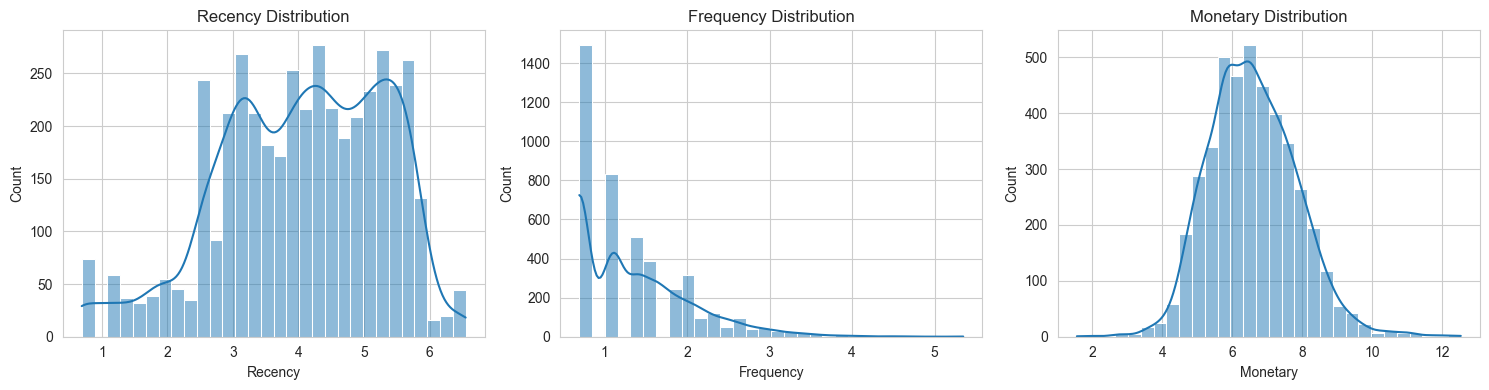

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Better style
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, len(rfm_log.columns), figsize=(15, 4))

for ax, col in zip(axes, rfm_log.columns):
    sns.histplot(
        data=rfm_log,
        x=col,
        kde=True,
        bins=30,
        ax=ax
    )
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

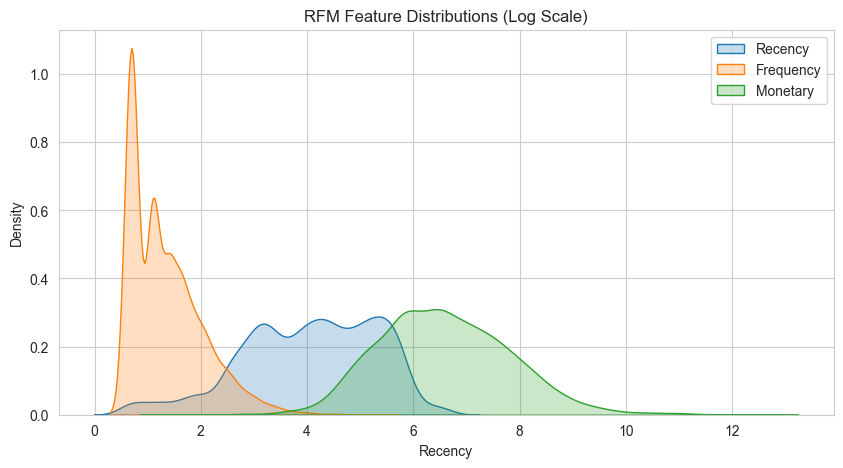

In [65]:
plt.figure(figsize=(10, 5))

for col in rfm_log.columns:
    sns.kdeplot(rfm_log[col], label=col, fill=True)

plt.title('RFM Feature Distributions (Log Scale)')
plt.legend()
plt.show()

In [66]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [67]:
rfm.columns

Index(['Customer_ID', 'Recency', 'Frequency', 'Monetary',
       'Average_Order_Value'],
      dtype='object')

<Axes: >

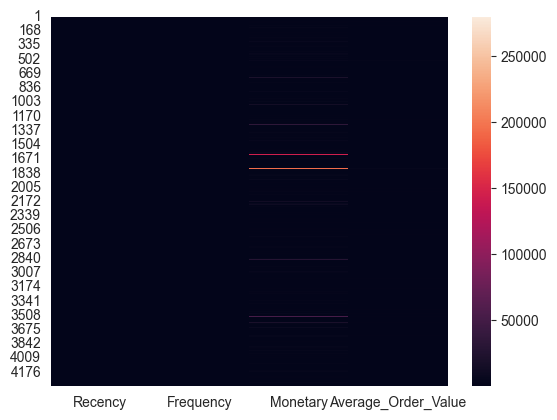

In [68]:
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary',
       'Average_Order_Value']])

In [69]:
rfm_scaled.shape

(4338, 3)

# Machine Learning - Elbow Method used

In [70]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [71]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

In [72]:
wcss

[13013.999999999989,
 6523.13850780692,
 4962.796658251131,
 4032.144148847804,
 3371.5090867889235,
 2903.1706800270813,
 2631.9928360834256,
 2390.058419332572,
 2204.6652197129306,
 2054.739679125143]

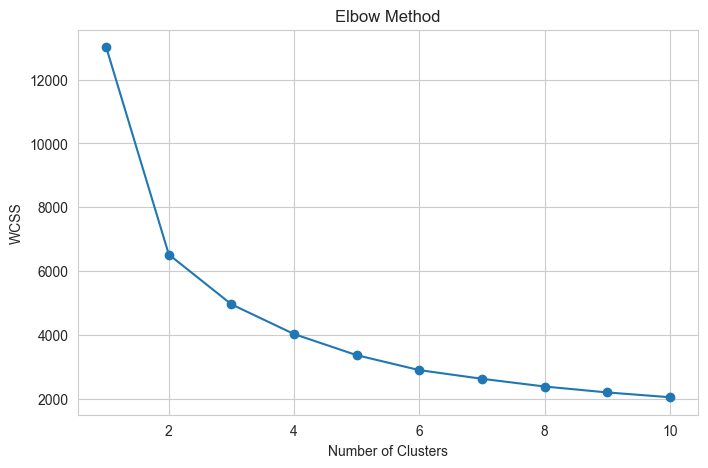

In [73]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

In [74]:
from sklearn.metrics import silhouette_score
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    print(f'K={k}, Score={score:.3f}')

K=2, Score=0.433
K=3, Score=0.336
K=4, Score=0.334
K=5, Score=0.317
K=6, Score=0.312
K=7, Score=0.311
K=8, Score=0.303
K=9, Score=0.280
K=10, Score=0.278


The Elbow Method shows a noticeable bend around 4. While the highest silhouette score occurred at K=2, four clusters provide more meaningful business segmentation and actionable customer groups.

In [75]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [76]:
rfm['Cluster'].value_counts()

Cluster
1    1661
0    1165
3     878
2     634
Name: count, dtype: int64

In [77]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,73.11,4.43,2067.61
1,207.04,1.38,363.77
2,16.86,14.60,8524.71
3,25.19,2.07,534.80


In [78]:
rfm.groupby('Cluster').agg({
    'Recency':['mean','median'],
    'Frequency':['mean','median'],
    'Monetary':['mean','median','sum'],
    'Cluster':'count'
}).round(2)

Recency        Frequency        Monetary                      Cluster
           mean median      mean median     mean   median         sum   count
Cluster                                                                      
0         73.11   61.0      4.43    4.0  2067.61  1475.81  2408766.42    1165
1        207.04  187.0      1.38    1.0   363.77   306.94   604222.92    1661
2         16.86   12.0     14.60   11.0  8524.71  3923.64  5404667.97     634
3         25.19   23.0      2.07    2.0   534.80   464.74   469551.58     878

In [79]:
# Every customer have cluster assigned
rfm.head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster
1,AA-13079,23,5,220.10,44.020000,3
2,AA-13425,110,3,1624.21,541.403333,0
3,AA-13805,54,2,924.60,462.300000,0
4,AA-13960,23,2,230.22,115.110000,3
5,AA-15045,34,2,735.66,367.830000,3


In [80]:
cluster_map = {
    0: 'Loyal Customers',
    1: 'At-Risk Customers',
    2: 'VIP Customers',
    3: 'Potential Customers'
}

In [81]:
rfm['Segment'] = rfm['Cluster'].map(cluster_map)

In [82]:
rfm.head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
1,AA-13079,23,5,220.10,44.020000,3,Potential Customers
2,AA-13425,110,3,1624.21,541.403333,0,Loyal Customers
3,AA-13805,54,2,924.60,462.300000,0,Loyal Customers
4,AA-13960,23,2,230.22,115.110000,3,Potential Customers
5,AA-15045,34,2,735.66,367.830000,3,Potential Customers


In [83]:
vip_customers = rfm[rfm['Segment']=='VIP Customers']
vip_customers.head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
12,AA-18283,11,16,2045.53,127.845625,2,VIP Customers
14,AB-12500,25,11,4257.82,387.074545,2,VIP Customers
15,AB-12919,3,6,1335.19,222.531667,2,VIP Customers
28,AB-15687,25,9,2993.10,332.566667,2,VIP Customers
29,AB-15993,18,7,2777.67,396.810000,2,VIP Customers


In [84]:
vip_customers.sort_values(by='Monetary', ascending=False).head(20)

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
972,DC-14646,3,73,280206.02,3838.438630,2,VIP Customers
39,AB-18102,13,60,259657.30,4327.621667,2,VIP Customers
1784,JG-17450,4,46,194390.79,4225.886739,2,VIP Customers
1620,JB-14911,1,201,143711.17,714.980945,2,VIP Customers
1285,EF-12415,26,21,124914.53,5948.310952,2,VIP Customers
328,AV-14156,1,55,117210.08,2131.092364,2,VIP Customers
1566,HW-17511,7,31,91062.38,2937.496129,2,VIP Customers
3155,MW-16029,31,63,80850.84,1283.346667,2,VIP Customers
1828,JH-16684,13,28,66653.56,2380.484286,2,VIP Customers
461,BI-14096,13,17,65164.79,3833.222941,2,VIP Customers


In [85]:
at_risk = rfm[rfm['Segment']=='At-Risk Customers']
at_risk.head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
8,AA-15844,48,1,130.74,130.74,1,At-Risk Customers
18,AB-13799,118,2,688.86,344.43,1,At-Risk Customers
19,AB-13856,96,3,388.50,129.50,1,At-Risk Customers
22,AB-14143,135,1,115.80,115.80,1,At-Risk Customers
33,AB-16595,92,1,360.16,360.16,1,At-Risk Customers


In [86]:
# Frequent Customers
rfm.sort_values(
    by='Frequency',
    ascending=False
).head(10)

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
1268,EC-12748,5,209,33053.19,158.149234,2,VIP Customers
1620,JB-14911,1,201,143711.17,714.980945,2,VIP Customers
1840,JH-17841,1,124,40519.84,326.772903,2,VIP Customers
2922,MK-13089,7,97,58762.08,605.794639,2,VIP Customers
2171,JW-14606,6,93,12076.15,129.851075,2,VIP Customers
1441,GD-15311,1,91,60632.75,666.293956,2,VIP Customers
109,AH-12971,10,86,11189.91,130.115233,2,VIP Customers
972,DC-14646,3,73,280206.02,3838.438630,2,VIP Customers
3155,MW-16029,31,63,80850.84,1283.346667,2,VIP Customers
2852,MH-13408,4,62,28117.04,453.500645,2,VIP Customers


In [87]:
# Churn risk customers
rfm.sort_values(
    by='Recency',
    ascending=False
).head(10)

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
1429,FS-17968,698,1,265.10,265.10,1,At-Risk Customers
2691,MA-16274,698,1,351.75,351.75,1,At-Risk Customers
523,BR-14142,698,1,311.81,311.81,1,At-Risk Customers
912,CW-15350,698,1,115.65,115.65,1,At-Risk Customers
3400,RA-14237,698,1,161.00,161.00,1,At-Risk Customers
163,AK-15922,698,1,369.50,369.50,1,At-Risk Customers
904,CW-13065,698,1,205.86,205.86,1,At-Risk Customers
2532,LD-17643,698,1,101.55,101.55,1,At-Risk Customers
1601,JB-12791,698,1,192.60,192.60,1,At-Risk Customers
1595,JA-18074,698,1,489.60,489.60,1,At-Risk Customers


In [88]:
rfm.to_csv(
    'customer_segments.csv',
    index=True
)

In [89]:
rfm['Monetary'].max()

np.float64(280206.02)

In [90]:
rfm['Monetary'].min()

np.float64(3.75)

In [91]:
rfm.sort_values('Monetary').head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
579,CA-16738,299,1,3.75,3.75,1,At-Risk Customers
1941,JM-14792,154,1,6.20,6.20,1,At-Risk Customers
2335,KJ-16454,46,2,6.90,3.45,1,At-Risk Customers
551,BS-17956,251,1,12.75,12.75,1,At-Risk Customers
2295,KG-16878,85,1,13.30,13.30,1,At-Risk Customers


In [92]:
rfm['Monetary'].sum()

np.float64(8887208.89)

In [93]:
rfm.head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
1,AA-13079,23,5,220.10,44.020000,3,Potential Customers
2,AA-13425,110,3,1624.21,541.403333,0,Loyal Customers
3,AA-13805,54,2,924.60,462.300000,0,Loyal Customers
4,AA-13960,23,2,230.22,115.110000,3,Potential Customers
5,AA-15045,34,2,735.66,367.830000,3,Potential Customers


In [94]:
rfm1=rfm.copy()

In [95]:
rfm1['Monetary_Norm']=(rfm1['Monetary']-min(rfm1['Monetary']))/(max(rfm1['Monetary'])-min(rfm1['Monetary']))

In [96]:
rfm1['Monetary_Norm'].describe()

count    4338.000000
mean        0.007298
std         0.032067
min         0.000000
25%         0.001080
50%         0.002373
75%         0.005913
max         1.000000
Name: Monetary_Norm, dtype: float64

In [97]:
rfm['Average_Order_Value'].describe()

count     4338.000000
mean       417.645734
std       1796.511343
min          3.450000
25%        177.867083
50%        291.940000
75%        428.280625
max      84236.250000
Name: Average_Order_Value, dtype: float64

In [102]:
import pandas as pd
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "GreaterTime###8"
host = "localhost"
port = 3306
database = "meesho"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

try:
   
    # Upload to MySQL
    df.to_sql(
        name="df",
        con=engine,
        if_exists="replace",   # or "append"
        index=False
    )

    print("✅ Data uploaded successfully!")

except Exception as e:
    print("❌ Upload failed!")
    print(e)

❌ Upload failed!
(pymysql.err.OperationalError) (1045, "Access denied for user 'root'@'localhost' (using password: YES)")
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [99]:
! pip install pymysql

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
